# Table of Contents

- [1. DATA UNDERSTANDING](#1-data-understanding)
  - [1.1. feature information](#11-feature-information)
  - [1.2. feature description](#12-feature-description)
  - [1.3. Target distribution](#13-target-distribution)


- [2. DATA EXPLORATION](#2-data-exploration)
  - [2.1. numeric data distribution](#21-numeric-data-distribution)
  - [2.2. Categorical variables](#22-categorical-variables)

In [1]:
# -----  Imports -------- #

# Sytem
import sys
from pathlib import Path

# Data cleaning
from ucimlrepo import fetch_ucirepo
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

# Own functions
sys.path.append(str(Path.cwd().parent / "src"))
from clinical_risk.plotting import (plot_grid,
                                    plot_countplot,
                                    plot_boxplot,
                                    plot_histogram,
                                    plot_clinical_boxplot)

from clinical_risk.descriptive import (iqr_outlier_summary,
                                        compare_skew)

# 1 DATA UNDERSTANDING

## 1.1 feature information

In [2]:
# fetch dataset 
data = fetch_ucirepo(id=519)

# variable infor
print(data.metadata.additional_info.variable_info)

Thirteen (13) clinical features:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- creatinine phosphokinase  (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction  (percentage)
- high blood pressure: if the patient has hypertension (boolean)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- [target] death event: if the patient died during the follow-up period (boolean)

For more information, please check Table 1, Table 2, and Table 3 of the following paper: 

Davide Chicco, Giuseppe Jurman: "Machine learning can predict survival of patients with heart failure from serum cr

## 1.2 feature description

In [3]:
X = data.data.features 
y = data.data.targets

df = pd.concat([y, X ], axis=1)

In [4]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
dtypes: float64(3), int64(9)
memory usage: 28.2 KB


In [5]:
X.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
dtype: int64

In [6]:
n_duplicates = df.duplicated().sum()
print(f"Número de filas duplicadas: {n_duplicates}")

Número de filas duplicadas: 0


In [7]:
missing = df.isna().sum().sort_values(ascending=False)
missing_percentage = (df.isna().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percentage": missing_percentage
})

missing_df

,missing_count,missing_percentage
death_event,0,0.0
age,0,0.0
anaemia,0,0.0
creatinine_phosphokinase,0,0.0
diabetes,0,0.0
ejection_fraction,0,0.0
high_blood_pressure,0,0.0
platelets,0,0.0
serum_creatinine,0,0.0
serum_sodium,0,0.0


## 1.4 Data formating

In [8]:
cat_cols = [ "sex","smoking","diabetes","high_blood_pressure","anaemia"]
df[cat_cols] = df[cat_cols].astype("category")


target = "death_event"
categorical_cols  = df.select_dtypes(include=["category"]).columns
numerical_cols = df.select_dtypes(include="number").columns.tolist()

In [9]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
death_event,299.0,0.321070,0.467670,0.0,0.0,0.0,1.0,1.0
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
time,299.0,130.260870,77.614208,4.0,73.0,115.0,203.0,285.0


In [10]:
df[categorical_cols].describe().T

,count,unique,top,freq
anaemia,299,2,0,170
diabetes,299,2,0,174
high_blood_pressure,299,2,0,194
sex,299,2,1,194
smoking,299,2,0,203


## 1.4 Target distribution

In [11]:
print("Outcome distribution:")
print(y.value_counts())
print("\nProportion:")
print(y.value_counts(normalize=True))

Outcome distribution:
death_event
0              203
1               96
Name: count, dtype: int64

Proportion:
death_event
0              0.67893
1              0.32107
Name: proportion, dtype: float64


# DATA EXPLORATION

## Univariate distributions

### numeric data distribution

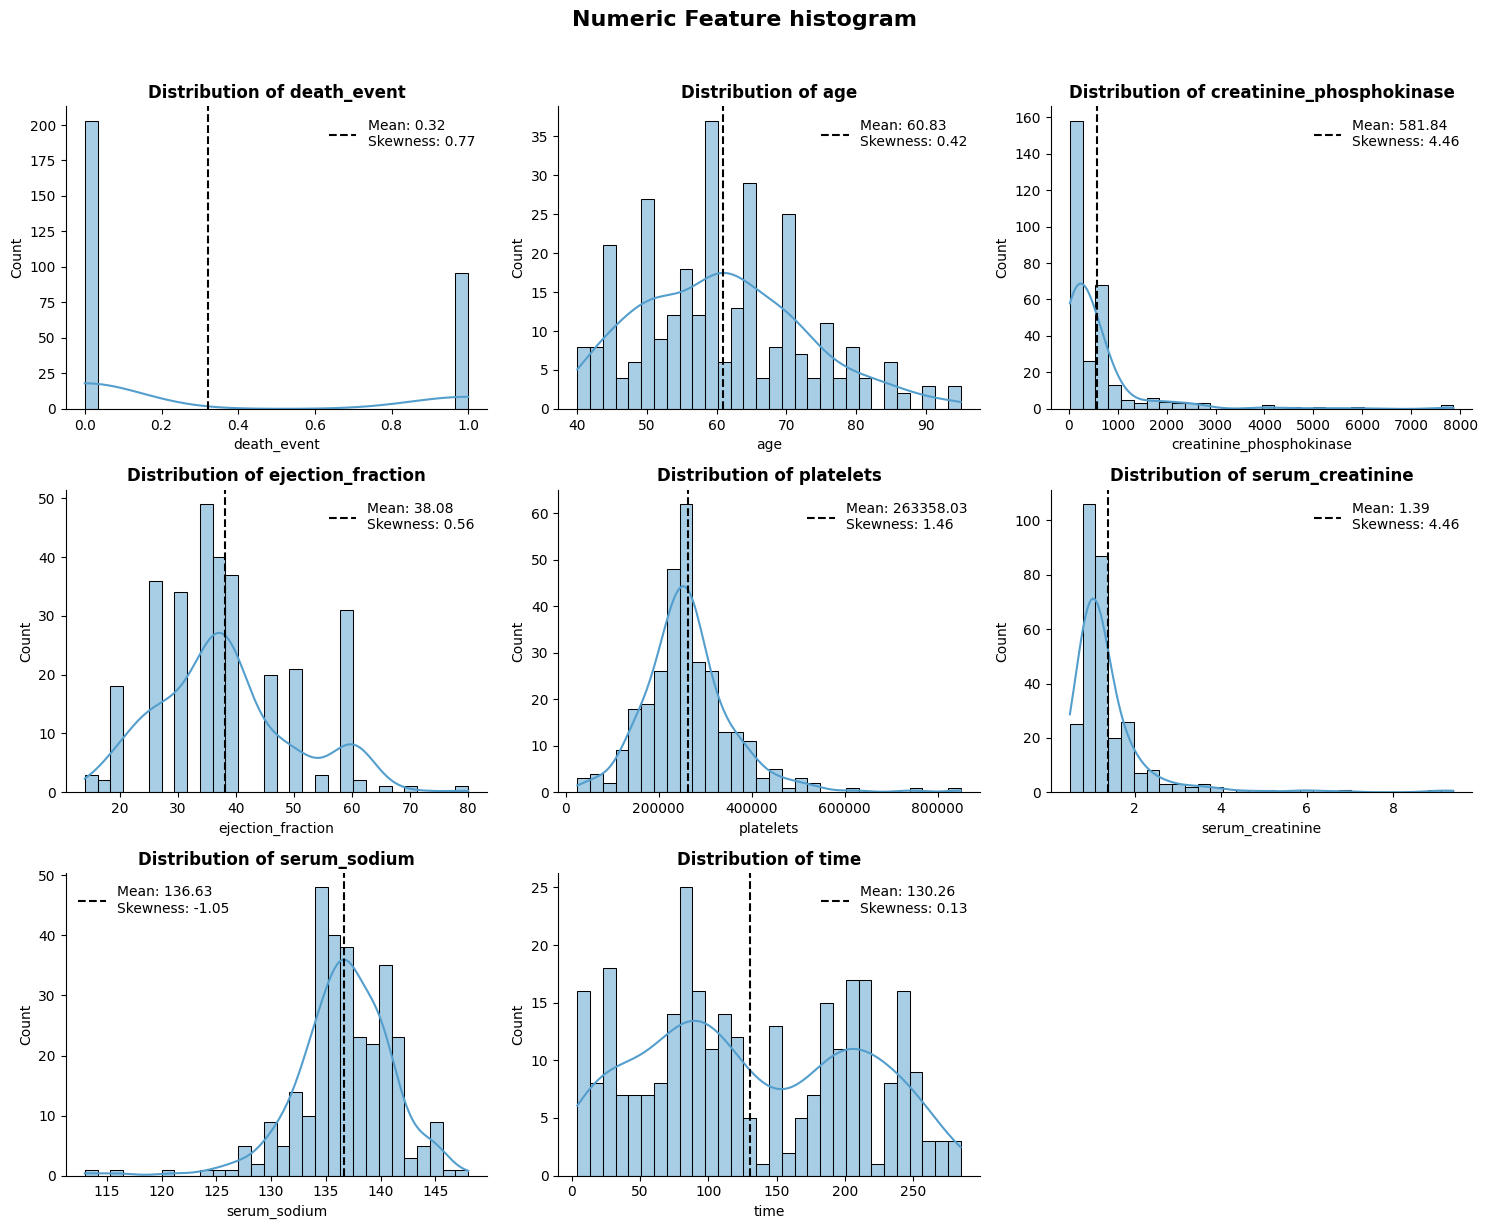

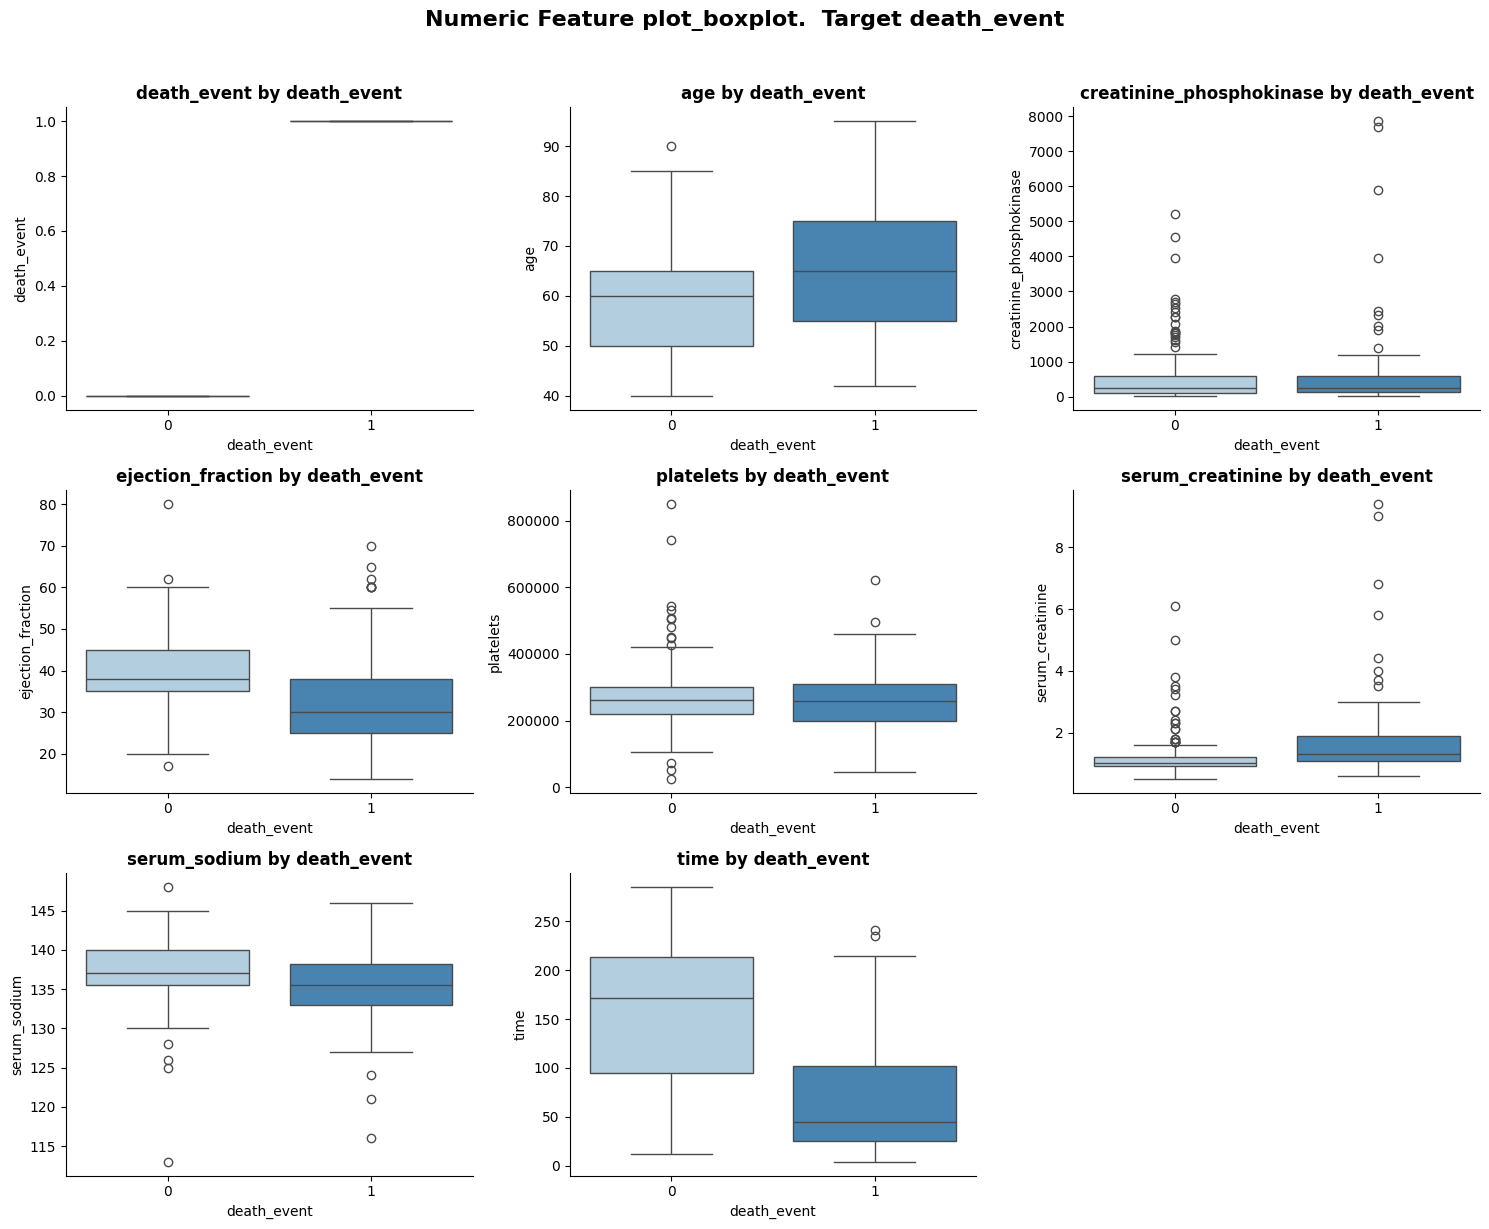

In [12]:
#Get histogram distribution
plot_grid(
    df=df,
    columns=numerical_cols,
    plot_func= plot_histogram,
    title="Numeric Feature histogram")


#Get boxplot distribution
plot_grid(
    df=df,
    columns=numerical_cols,
    plot_func= plot_boxplot,
    title="Numeric Feature plot_boxplot.  Target death_event",
    target = "death_event")

### numeric outlier

In [13]:
#Get iqr and outlier proportions
outlier_summary = iqr_outlier_summary(df, numerical_cols)


# Find outliers based on iqr to study
limits = outlier_summary.set_index("variable")[["lower_bound","upper_bound"]].to_dict("index")
mask = pd.Series(True, index=df.index)
for col, lim in limits.items():
    mask &= df[col].between(lim["lower_bound"], lim["upper_bound"])

invalid_rows = df[~mask]
outlier_summary

,variable,q1,q3,iqr,lower_bound,upper_bound,n_outliers,outlier_pct
2,creatinine_phosphokinase,116.5,582.0,465.5,-581.75,1280.25,29,9.698997
5,serum_creatinine,0.9,1.4,0.5,0.15,2.15,29,9.698997
4,platelets,212500.0,303500.0,91000.0,76000.00,440000.00,21,7.023411
6,serum_sodium,134.0,140.0,6.0,125.00,149.00,4,1.337793
3,ejection_fraction,30.0,45.0,15.0,7.50,67.50,2,0.668896
1,age,51.0,70.0,19.0,22.50,98.50,0,0.000000
0,death_event,0.0,1.0,1.0,-1.50,2.50,0,0.000000
7,time,73.0,203.0,130.0,-122.00,398.00,0,0.000000


* Laboratory reference ranges:
| Parameter                                         | Reference Range | Extreme (Clinically Possible)                        | Impossible / Data Error |
| ------------------------------------------------- | --------------- | ---------------------------------------------------- | ----------------------- |
| **Serum creatinine (mg/dL)**                      | 0.6 – 1.3       | 5 – 20 (severe renal failure)                        | <0 or >40               |
| **Serum sodium (mEq/L)**                          | 135 – 145       | 110 – 160 (severe electrolyte imbalance)             | <90 or >200             |
| **Platelets (×10³/µL)**                           | 150 – 450       | 10 – 1000 (severe thrombocytopenia / thrombocytosis) | <0 or >2000             |
| **Ejection fraction (%)**                         | 50 – 70         | 10 – 80 (severe heart failure or hyperdynamic state) | <0 or >100              |
| **Creatinine phosphokinase – CPK (U/L or mcg/L)** | 20 – 200        | 1000 – 10000+ (rhabdomyolysis, major muscle injury)  | <0 or >200000           |






* cleaning boundaries:  physiologically plausible limits often used in data validation or outlier filtering for clinical datasets
| Parameter                      | Lower Bound | Upper Bound | Units   |
| ------------------------------ | ----------- | ----------- | ------- |
| Serum creatinine               | 0.1         | 20          | mg/dL   |
| Serum sodium                   | 110         | 160         | mEq/L   |
| Platelets                      | 10          | 1000        | ×10³/µL |
| Ejection fraction              | 5           | 90          | %       |
| Creatinine phosphokinase (CPK) | 10          | 100000      | U/L     |


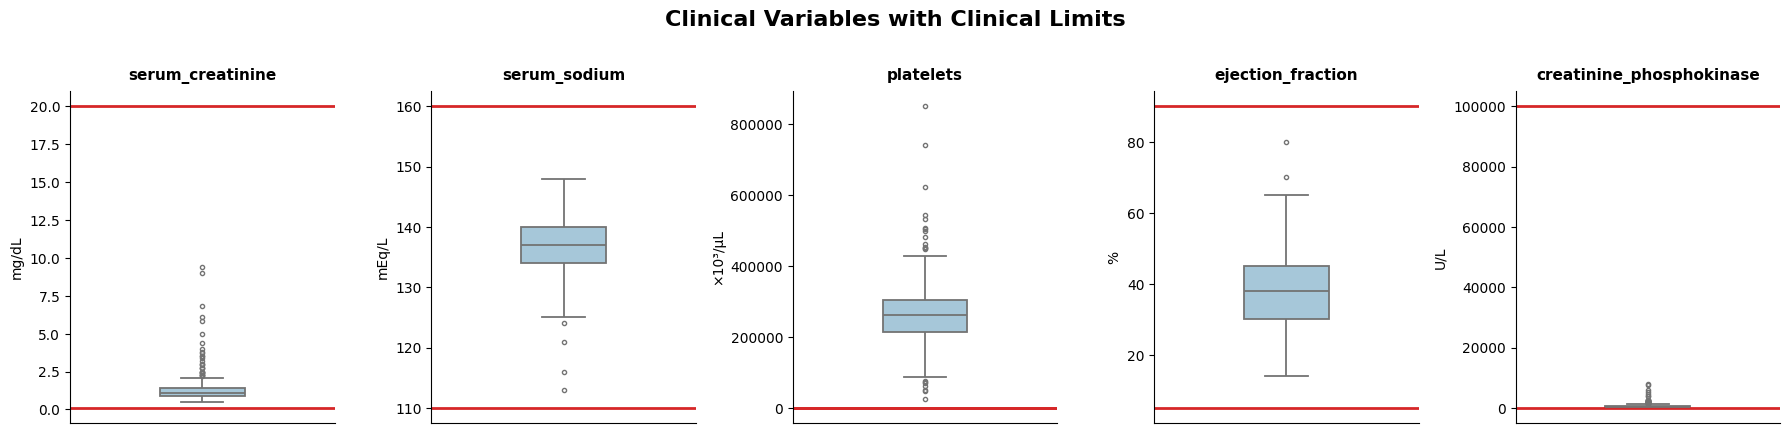

In [14]:
# Clinical imposible values
df_limits = pd.DataFrame({
    "variable": [
        "serum_creatinine",
        "serum_sodium",
        "platelets",
        "ejection_fraction",
        "creatinine_phosphokinase"
    ],
    "clinical_lower": [0.1, 110, 10, 5, 10],
    "clinical_upper": [20, 160, 1000, 90, 100000],
    "units": ["mg/dL", "mEq/L", "×10³/µL", "%", "U/L"]
})


df_limits_plot = df_limits.set_index("variable")
vars_to_plot = df_limits_plot.index.tolist()

plot_grid(
    df=df,
    columns=vars_to_plot,
    plot_func=plot_clinical_boxplot,
    title="Clinical Variables with Clinical Limits",
    n_cols=5,
    figsize=(18, 4.2),
    df_limits_plot=df_limits_plot
)

### skwness score

In [22]:
skew_table=compare_skew(df,numerical_cols)
skew_table

,variable,original_skew,log_skew,abs_original_skew,abs_log_skew,improvement
2,creatinine_phosphokinase,4.463110,0.422715,4.463110,0.422715,4.040395
5,serum_creatinine,4.455996,2.313207,4.455996,2.313207,2.142789
1,age,0.423062,-0.009504,0.423062,0.009504,0.413558
3,ejection_fraction,0.555383,-0.245770,0.555383,0.245770,0.309613
4,platelets,1.462321,-1.284928,1.462321,1.284928,0.177393
0,death_event,0.770349,0.770349,0.770349,0.770349,0.000000
6,serum_sodium,-1.048136,-1.310145,1.048136,1.310145,-0.262009
7,time,0.127803,-1.179780,0.127803,1.179780,-1.051977


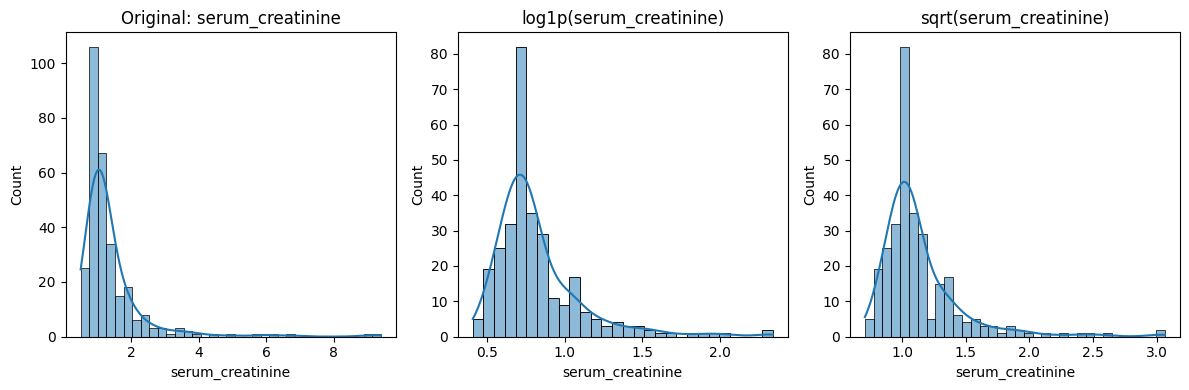

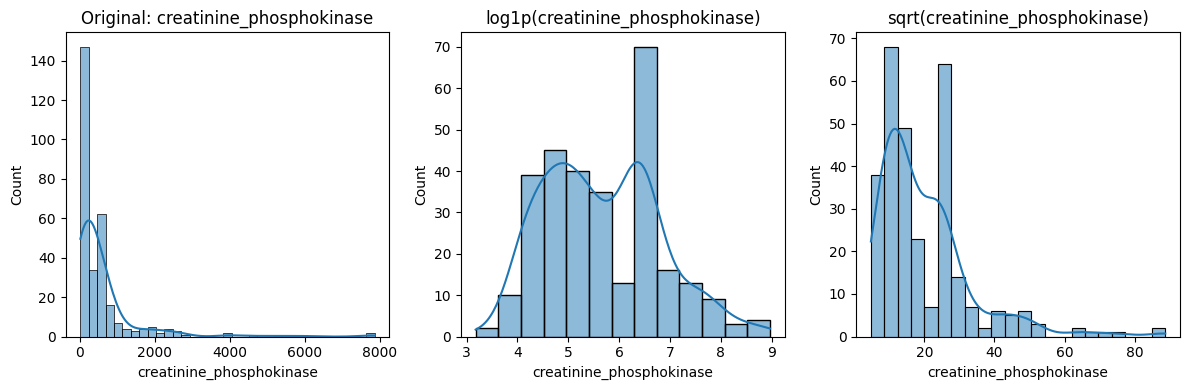

In [24]:
log_candidates = ["serum_creatinine", "creatinine_phosphokinase"]

for col in log_candidates:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Original: {col}")
    
    sns.histplot(np.log1p(df[col]), kde=True, ax=axes[1])
    axes[1].set_title(f"log1p({col})")

    sns.histplot(np.sqrt(df[col]), kde=True, ax=axes[2])
    axes[2].set_title(f"sqrt({col})")
    
    plt.tight_layout()
    plt.show()

In [16]:
skew_check = pd.DataFrame({
    "variable": ["serum_creatinine", "creatinine_phosphokinase"],
    "original_skew": [
        df["serum_creatinine"].skew(),
        df["creatinine_phosphokinase"].skew()
    ],
    "log_skew": [
        np.log1p(df["serum_creatinine"]).skew(),
        np.log1p(df["creatinine_phosphokinase"]).skew()
    ]
})

skew_check


,variable,original_skew,log_skew
0,serum_creatinine,4.455996,2.313207
1,creatinine_phosphokinase,4.463110,0.422715


In [17]:
skew_check

,variable,original_skew,log_skew
0,serum_creatinine,4.455996,2.313207
1,creatinine_phosphokinase,4.463110,0.422715


### Categorical variables

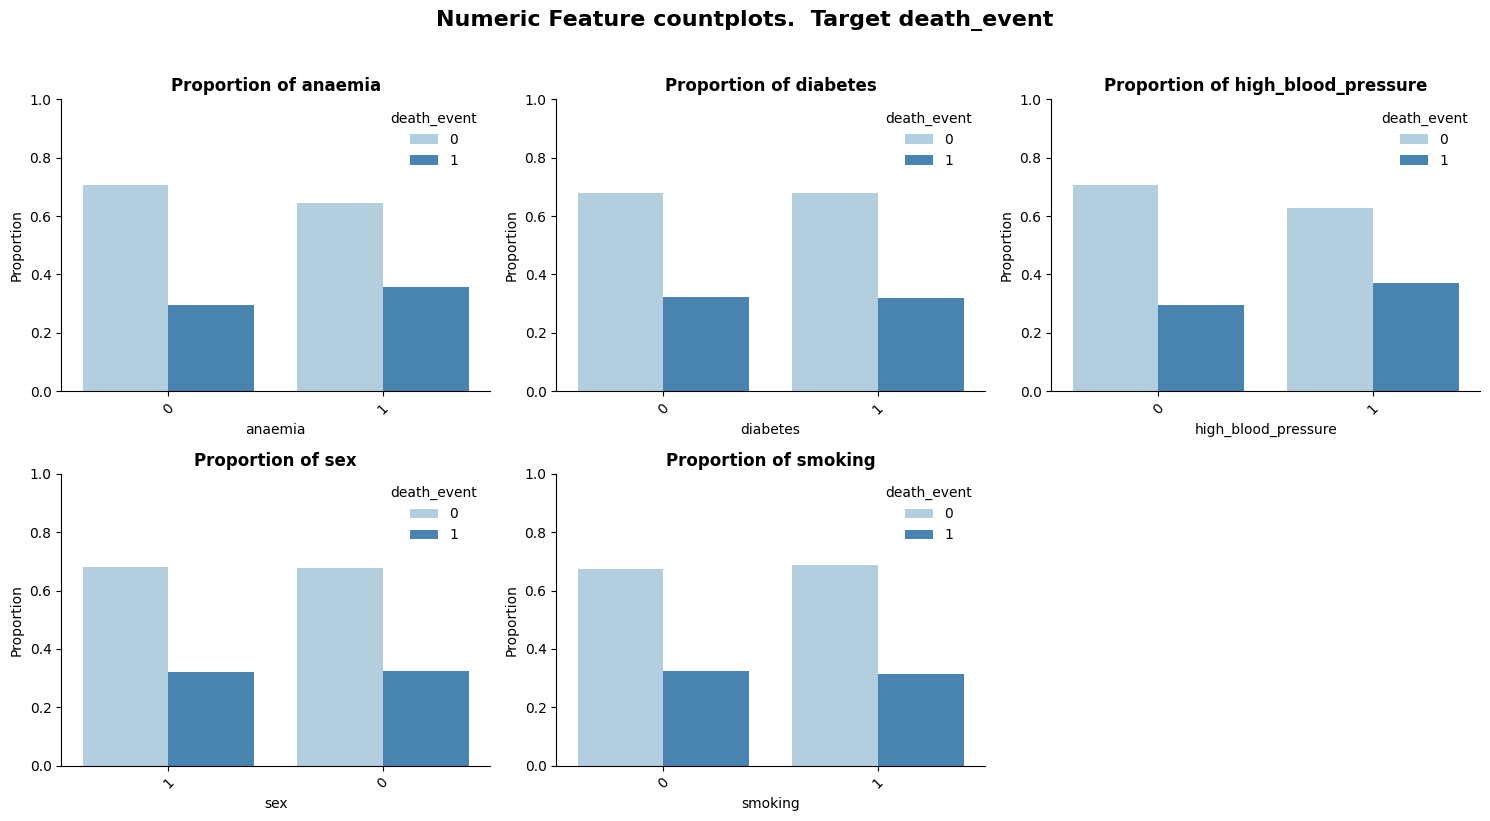

In [18]:
#Get boxplot distribution
plot_grid(
    df=df,
    columns=categorical_cols,
    plot_func= plot_countplot,
    title="Numeric Feature countplots.  Target death_event",
    target = "death_event"
    )

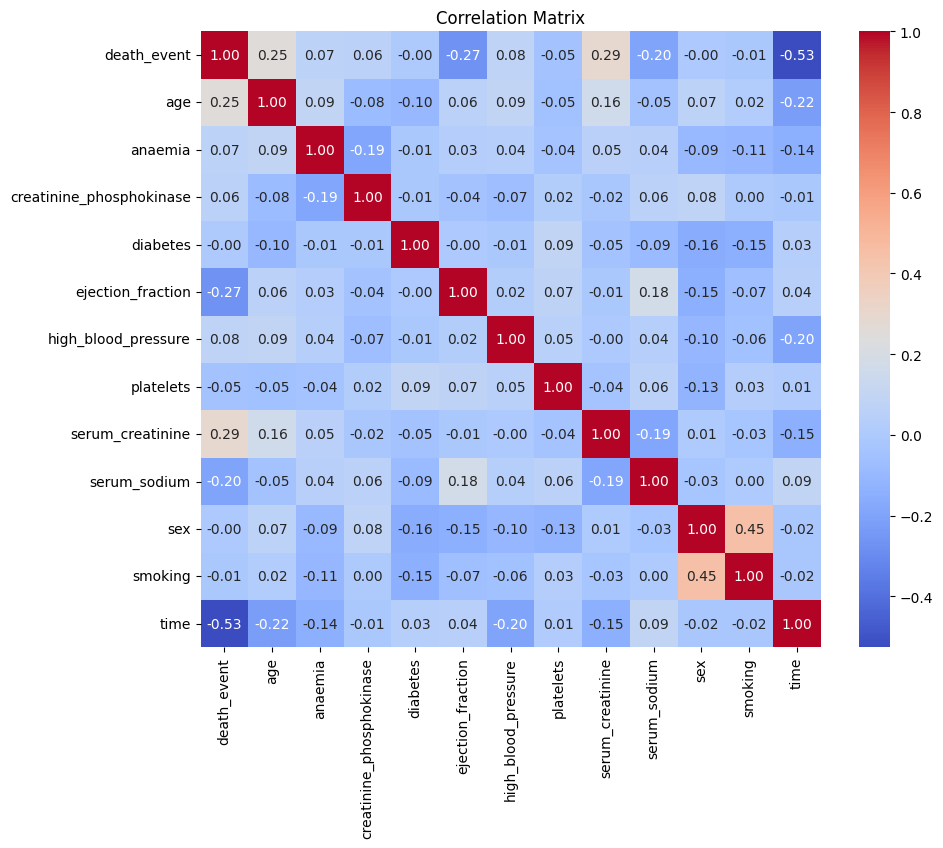

In [19]:
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

## Bivariate distribution. Key variables

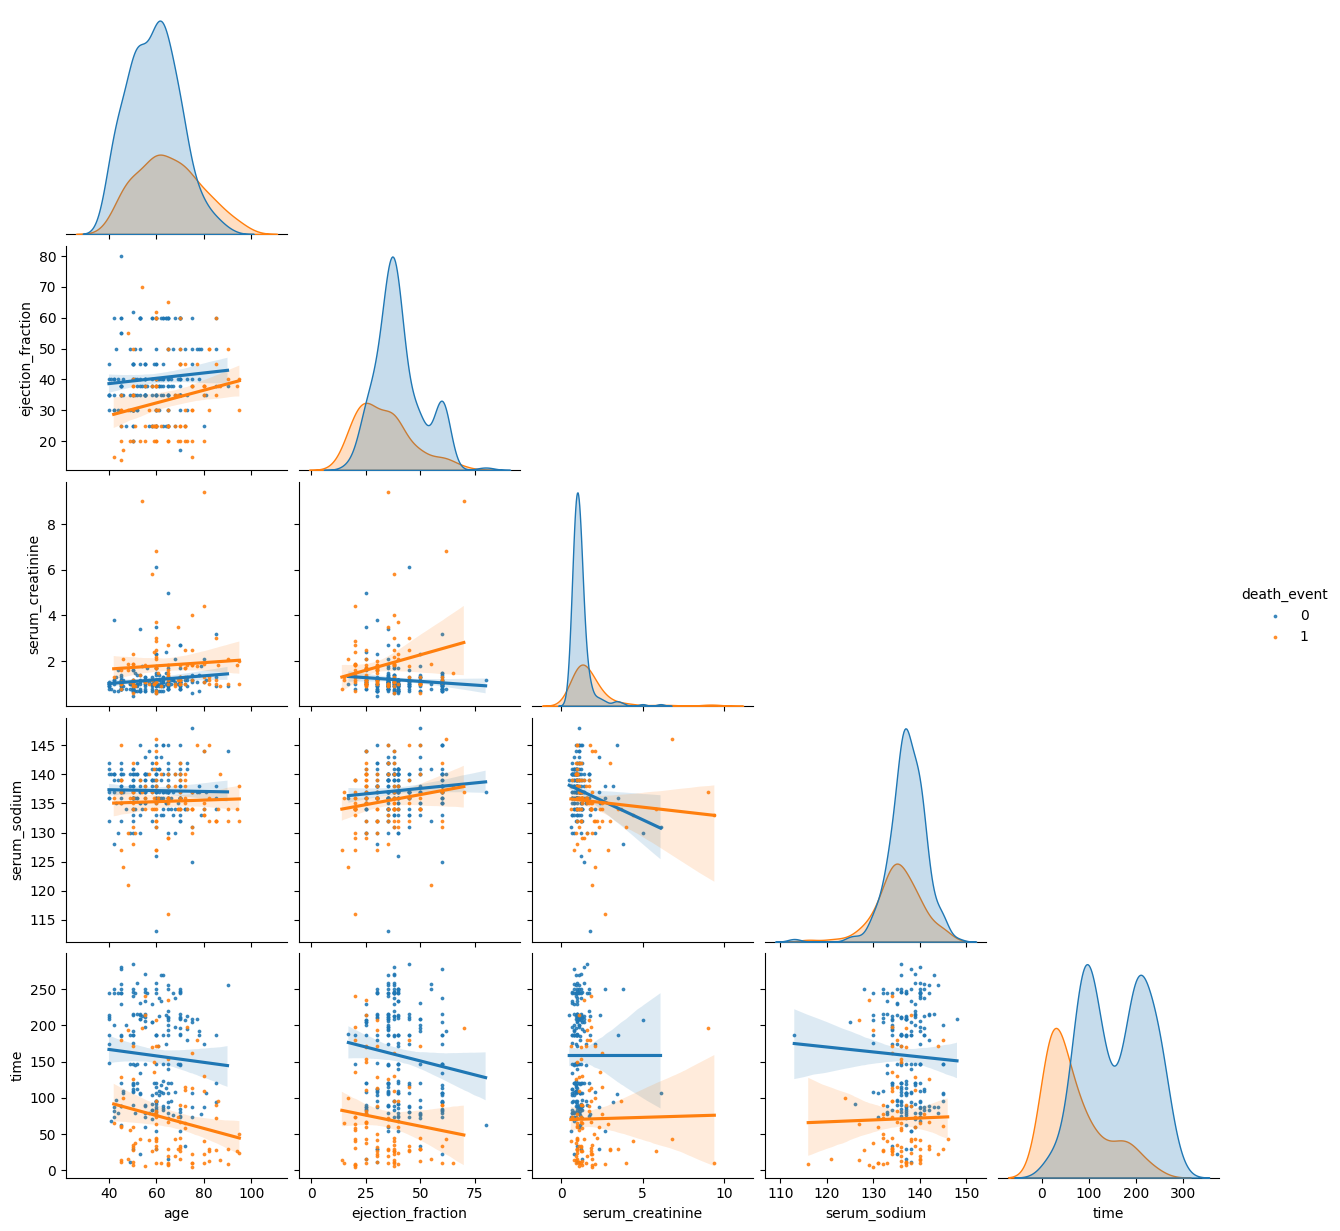

In [20]:
selected_cols = ["age", "ejection_fraction", "serum_creatinine", "serum_sodium", "time", "death_event"]
sns.pairplot(df[selected_cols],
             hue="death_event",
             corner=True,
             kind= 'reg',
             diag_kind= 'kde',
             plot_kws=dict(scatter_kws=dict(s=3)))
plt.show()